In [1]:
#Importation des données
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import shutil
import os
import seaborn as sns
import re
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.neural_network import MLPRegressor


# Paramètres
TOP_K_MODELS = 100  #

Nettoyage et fusion des datasets

1- Ajout des colonnes presents dans certains datasets mais manquants dans d'autres

In [306]:
def add_column_with_NaN(path,column,delimiter=','):
    # 1. Créer un DataFrame à partir d'un fichier CSV
    df = pd.read_csv(path,delimiter=delimiter)

    # Crée le dossier si elle n'existe pas
    dossier_temporaire = 'Dossier_Temporaire'
    os.makedirs(dossier_temporaire, exist_ok=True)

    if 'mars-2014-complete.csv' in path :
        df.to_csv(dossier_temporaire+'/'+path.split('/')[1], index=False)
        return

    # 3. Ajouter une nouvelle colonne avec  NaN
    df[column] = np.nan

    

    


    # 5. Sauvegarder le DataFrame modifié 
    df.to_csv(dossier_temporaire+'/'+path.split('/')[1], index=False)


add_column_with_NaN('source_de_donnees/1-fic_etiq_edition_janvier2001.csv','masse orde marche min')
add_column_with_NaN('source_de_donnees/1-fic_etiq_edition_janvier2001.csv','masse orde marche max')

add_column_with_NaN('source_de_donnees/CO2 Emissions_Canada.csv','masse orde marche min')
add_column_with_NaN('source_de_donnees/CO2 Emissions_Canada.csv','masse orde marche max')

add_column_with_NaN('source_de_donnees/1-fic_etiq_edition_janvier2001_2.csv','masse orde marche min')
add_column_with_NaN('source_de_donnees/1-fic_etiq_edition_janvier2001_2.csv','masse orde marche max')

add_column_with_NaN('source_de_donnees/1-fic_etiq_edition_janvier2001_3.csv','masse orde marche min')
add_column_with_NaN('source_de_donnees/1-fic_etiq_edition_janvier2001_3.csv','masse orde marche max')

add_column_with_NaN('source_de_donnees/1-fic_etiq_edition_janvier2001_4.csv','masse orde marche min')
add_column_with_NaN('source_de_donnees/1-fic_etiq_edition_janvier2001_4.csv','masse orde marche max')


add_column_with_NaN('source_de_donnees/3-fic_etiq_edition_01_maj_dec2002.csv','masse orde marche min')
add_column_with_NaN('source_de_donnees/3-fic_etiq_edition_01_maj_dec2002.csv','masse orde marche max')
add_column_with_NaN('source_de_donnees/7-fic_etiq_edition_janvier2005.csv','masse orde marche min')
add_column_with_NaN('source_de_donnees/7-fic_etiq_edition_janvier2005.csv','masse orde marche max')

add_column_with_NaN('source_de_donnees/9-fic_etiq_edition_janvier_2007.csv','masse orde marche min')
add_column_with_NaN('source_de_donnees/9-fic_etiq_edition_janvier_2007.csv','masse orde marche min')

add_column_with_NaN('source_de_donnees/mars-2014-complete.csv','masse orde marche min')
add_column_with_NaN('source_de_donnees/mars-2014-complete.csv','masse orde marche min')


2-Renomage des colonnes

In [307]:
def rename_columns(file_path, delimiter=',' , rename_map={}):
    """
    Renomme les colonnes d'un fichier CSV selon un dictionnaire de mapping fourni
    et sauvegarde le fichier mis à jour.

    Args:
        file_path (str): Le chemin d'accès au fichier CSV.
        delimiter (str): Le séparateur utilisé dans le fichier ('sep').
        rename_map (dict): Dictionnaire {Ancien Nom: Nouveau Nom}.
    """
    try:
        # 1. Charger le DataFrame avec le bon délimiteur
        df = pd.read_csv(file_path, delimiter=delimiter)

        # 2. Appliquer le renommage
        # On utilise errors='ignore' pour éviter une erreur si une colonne
        # à renommer n'existe plus (utile après une première exécution).
        df.rename(columns=rename_map, inplace=True, errors='ignore')

        # 3. Sauvegarder le DataFrame modifié avec le même délimiteur
        df.to_csv(file_path, index=False, sep=delimiter)
        

    except FileNotFoundError:
        print(f"Erreur: Fichier '{file_path}' non trouvé.")
    except Exception as e:
        print(f"Une erreur est survenue lors du traitement de '{file_path}': {e}")



RENAME_MAP_FRANCE_OLD = {
    'MARQUES': 'Marque',
    'MODELE': 'Modèle',
    'BV': 'Transmission',
    'CARB': 'Type de Carburant',
    'Urbain': 'Consommation Urbaine (L/100 km)',
    'Ex.Urb': 'Consommation Autoroute (L/100 km)',
    'Mixte': 'Consommation Mixte (L/100 km)',
    'CO2': 'Emissions CO2 (g/km)',
    'CV': 'Puissance Fiscale (CV)',
    'PUISS.': 'Puissance Moteur',
    
    # Colonnes ajoutées précédemment (pour unifier le schéma)
    'Vehicle Class': 'Catégorie de Véhicule',
    'Engine Size(L)': 'Cylindrée (L)',
    'Cylinders': 'Cylindres',
    'Fuel Consumption Comb (mpg)': 'Consommation Mixte (mpg)'
}

rename_columns('Dossier_Temporaire/1-fic_etiq_edition_janvier2001_2.csv', rename_map=RENAME_MAP_FRANCE_OLD)
rename_columns('Dossier_Temporaire/1-fic_etiq_edition_janvier2001_3.csv', rename_map=RENAME_MAP_FRANCE_OLD)
rename_columns('Dossier_Temporaire/1-fic_etiq_edition_janvier2001_4.csv', rename_map=RENAME_MAP_FRANCE_OLD)


RENAME_MAP_FRANCE_NEW = {
    'MARQUE': 'Marque',
    'MODELE VERSION': 'Modèle',
    'bv': 'Transmission',
    'CARB': 'Type de Carburant',
    'carburant': 'Type de Carburant', # Alternative pour certains fichiers
    'urb': 'Consommation Urbaine (L/100 km)',
    'ex-urb': 'Consommation Autoroute (L/100 km)',
    'mixte': 'Consommation Mixte (L/100 km)',
    'CO2': 'Emissions CO2 (g/km)',
    'puissance fiscale': 'Puissance Fiscale (CV)',
    'puissance reelle': 'Puissance Moteur',
    
    # Colonnes ajoutées précédemment (pour unifier le schéma)
    'Vehicle Class': 'Catégorie de Véhicule',
    'Engine Size(L)': 'Cylindrée (L)',
    'Cylinders': 'Cylindres',
    'Fuel Consumption Comb (mpg)': 'Consommation Mixte (mpg)'
}

rename_columns('Dossier_Temporaire/3-fic_etiq_edition_01_maj_dec2002.csv', rename_map=RENAME_MAP_FRANCE_NEW)
rename_columns('Dossier_Temporaire/7-fic_etiq_edition_janvier2005.csv', rename_map=RENAME_MAP_FRANCE_NEW)
rename_columns('Dossier_Temporaire/9-fic_etiq_edition_janvier_2007.csv', rename_map=RENAME_MAP_FRANCE_NEW)


RENAME_MAP_MARS2014 = {
    'Marque': 'Marque',
    'Model': 'Modèle',
    'typ_boite_nb_rapp': 'Transmission',
    'cod_cbr': 'Type de Carburant',
    'conso_urb': 'Consommation Urbaine (L/100 km)',
    'conso_exurb': 'Consommation Autoroute (L/100 km)',
    'conso_mixte': 'Consommation Mixte (L/100 km)',
    'co2': 'Emissions CO2 (g/km)',
    'puiss_admin_98': 'Puissance Fiscale (CV)',
    'puiss_max': 'Puissance Moteur',
    
    # Colonnes ajoutées précédemment (pour unifier le schéma)
    'Vehicle Class': 'Catégorie de Véhicule',
    'Engine Size(L)': 'Cylindrée (L)',
    'Cylinders': 'Cylindres',
    'Fuel Consumption Comb (mpg)': 'Consommation Mixte (mpg)'
}

rename_columns('Dossier_Temporaire/mars-2014-complete.csv', rename_map=RENAME_MAP_MARS2014)

RENAME_MAP_CANADA = {
    'Make': 'Marque',
    'Model': 'Modèle',
    'Vehicle Class': 'Catégorie de Véhicule',
    'Engine Size(L)': 'Cylindrée (L)',
    'Cylinders': 'Cylindres',
    'Transmission': 'Transmission',
    'Fuel Type': 'Type de Carburant',
    'Fuel Consumption City (L/100 km)': 'Consommation Urbaine (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)': 'Consommation Autoroute (L/100 km)',
    'Fuel Consumption Comb (L/100 km)': 'Consommation Mixte (L/100 km)',
    'Fuel Consumption Comb (mpg)': 'Consommation Mixte (mpg)',
    'CO2 Emissions(g/km)': 'Emissions CO2 (g/km)',
    
    # Colonnes ajoutées précédemment (pour unifier le schéma)
    'Tax Horsepower (CV)': 'Puissance Fiscale (CV)',
    'Engine Power': 'Puissance Moteur'
}

rename_columns('Dossier_Temporaire/CO2 Emissions_Canada.csv', rename_map=RENAME_MAP_CANADA)
rename_columns('Dossier_Temporaire/1-fic_etiq_edition_janvier2001.csv', rename_map=RENAME_MAP_CANADA)

Harmonisation des colonnes

In [308]:
# --- 1. Ordre Global des Colonnes (Final Standard) ---
FINAL_COLUMNS_ORDER = [
    'Marque',
    'Modèle',
    'Version Détaillée',
    'Catégorie de Véhicule',
    'Type de Carburant',
    'Hybride',
    'Cylindrée (L)',
    'Cylindres',
    'Transmission',
    'Puissance Moteur',
    'Puissance Fiscale (CV)',
    'Masse Min (kg)',
    'Masse Max (kg)',
    'Consommation Urbaine (L/100 km)',
    'Consommation Autoroute (L/100 km)',
    'Consommation Mixte (L/100 km)',
    'Emissions CO2 (g/km)'
]

def harmonize_and_reorder_file(file_path, delimiter):
    """
    Lit un fichier CSV, effectue le renommage final (nettoyage), 
    ajoute les colonnes manquantes et réordonne les colonnes selon 
    FINAL_COLUMNS_ORDER avant de sauvegarder le fichier.
    """
    if not os.path.exists(file_path):
        return f"❌ Erreur: Fichier '{file_path}' non trouvé."

    try:
        df = pd.read_csv(file_path, delimiter=delimiter, low_memory=False)

        # 1. Final Renaming/Cleanup
        rename_map = {
            'MODEL':'Modèle',
            'dscom': 'Version Détaillée',
            'hybride': 'Hybride',
            'gamme': 'Catégorie de Véhicule', 
            'masse_ordma_min': 'Masse Min (kg)',
            'masse_ordma_max': 'Masse Max (kg)',
            'masse orde marche min': 'Masse Min (kg)',
            'masse orde marche max': 'Masse Max (kg)',
            'Consommation Mixte (mpg)': 'COL_TO_DROP_MPG'
        }
        df.rename(columns=rename_map, inplace=True, errors='ignore')

        # 2. Drop unwanted columns AVANT d'ajouter les colonnes manquantes
        cols_to_drop = [
            'TYP. MINES', 'CNIT', 'ETIQUETTE ENERGIE',
            'COL_TO_DROP_MPG', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 
            'Unnamed: 13', '#REF!', '#REF!.1', '#REF!.2'
        ]
        df.drop(columns=[col for col in cols_to_drop if col in df.columns], 
                inplace=True, errors='ignore')

        # 3. Add Missing Final Columns (seulement celles qui n'existent pas)
        for col in FINAL_COLUMNS_ORDER:
            if col not in df.columns:
                df[col] = np.nan

        # 4. Final Reordering - CORRECTION ICI
        # Sélectionne les colonnes dans l'ordre, en gardant les données existantes
        final_df = df[FINAL_COLUMNS_ORDER]

        # 5. Sauvegarder le DataFrame modifié
        final_df.to_csv(file_path, index=False, sep=delimiter)

        return f"✅ Colonnes réordonnées et nettoyées pour '{file_path}'."

    except Exception as e:
        return f"❌ Une erreur est survenue lors du traitement de '{file_path}': {e}"


# --- Liste des Fichiers et Application de la Fonction ---

files_to_process = [
    # Séparateur Virgule (,)
    {'path': 'Dossier_Temporaire/CO2 Emissions_Canada.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/mars-2014-complete.csv', 'delimiter': ','},
    
    # Séparateur Point-Virgule (;)
    {'path': 'Dossier_Temporaire/1-fic_etiq_edition_janvier2001.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/1-fic_etiq_edition_janvier2001_2.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/1-fic_etiq_edition_janvier2001_3.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/1-fic_etiq_edition_janvier2001_4.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/3-fic_etiq_edition_01_maj_dec2002.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/7-fic_etiq_edition_janvier2005.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/9-fic_etiq_edition_janvier_2007.csv', 'delimiter': ','},
]

results = []
for file_info in files_to_process:
    results.append(harmonize_and_reorder_file(file_info['path'], file_info['delimiter']))

print("\n--- Résultat de l'opération ---")
for result in results:
    print(result)

print("\nL'ordre des colonnes est maintenant uniforme pour tous les fichiers.")


--- Résultat de l'opération ---
✅ Colonnes réordonnées et nettoyées pour 'Dossier_Temporaire/CO2 Emissions_Canada.csv'.
✅ Colonnes réordonnées et nettoyées pour 'Dossier_Temporaire/mars-2014-complete.csv'.
✅ Colonnes réordonnées et nettoyées pour 'Dossier_Temporaire/1-fic_etiq_edition_janvier2001.csv'.
✅ Colonnes réordonnées et nettoyées pour 'Dossier_Temporaire/1-fic_etiq_edition_janvier2001_2.csv'.
✅ Colonnes réordonnées et nettoyées pour 'Dossier_Temporaire/1-fic_etiq_edition_janvier2001_3.csv'.
✅ Colonnes réordonnées et nettoyées pour 'Dossier_Temporaire/1-fic_etiq_edition_janvier2001_4.csv'.
✅ Colonnes réordonnées et nettoyées pour 'Dossier_Temporaire/3-fic_etiq_edition_01_maj_dec2002.csv'.
✅ Colonnes réordonnées et nettoyées pour 'Dossier_Temporaire/7-fic_etiq_edition_janvier2005.csv'.
✅ Colonnes réordonnées et nettoyées pour 'Dossier_Temporaire/9-fic_etiq_edition_janvier_2007.csv'.

L'ordre des colonnes est maintenant uniforme pour tous les fichiers.


Fusion Des DataSets 

In [309]:
# Liste des fichiers et de leurs délimiteurs respectifs
files_data = [
    {'path': 'Dossier_Temporaire/CO2 Emissions_Canada.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/mars-2014-complete.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/1-fic_etiq_edition_janvier2001.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/1-fic_etiq_edition_janvier2001_2.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/1-fic_etiq_edition_janvier2001_3.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/1-fic_etiq_edition_janvier2001_4.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/3-fic_etiq_edition_01_maj_dec2002.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/7-fic_etiq_edition_janvier2005.csv', 'delimiter': ','},
    {'path': 'Dossier_Temporaire/9-fic_etiq_edition_janvier_2007.csv', 'delimiter': ','},
]

# Liste pour stocker tous les DataFrames chargés
list_of_dfs = []

print("Démarrage de la fusion...")

# Lecture et concaténation des fichiers
for file_info in files_data:
    file_path = file_info['path']
    delimiter = file_info['delimiter']
    
    if os.path.exists(file_path):
        try:
            # La lecture utilise le délimiteur spécifique à chaque fichier
            df = pd.read_csv(file_path, delimiter=delimiter, low_memory=False)
            
            
            list_of_dfs.append(df)
            print(f"Chargé : {file_path} ({len(df)} lignes)")
            
        except Exception as e:
            print(f"Erreur de chargement pour {file_path} : {e}")
    else:
        print(f"Fichier non trouvé : {file_path}. Ignoré.")

# Concaténation de tous les DataFrames
# Puisque l'ordre des colonnes est le même pour tous, la concaténation est garantie d'être correcte.
df_global = pd.concat(list_of_dfs, ignore_index=True)

# Sauvegarde du fichier global
output_file = 'CO2_Emissions_Global_Dataset.csv'
# On choisit le délimiteur virgule (,) pour la sortie globale, qui est la norme CSV
df_global.to_csv(output_file, index=False, sep=',')

#Suppression du doosier Temporaire
dossier_a_supprimer = "Dossier_Temporaire"
if os.path.exists(dossier_a_supprimer):
    try:
        # 2. Suppression récursive (Dossier + Contenu)
        shutil.rmtree(dossier_a_supprimer)
        print(f"Le dossier '{dossier_a_supprimer}' et tout son contenu ont été supprimés.")
    except OSError as e:
        print(f"Erreur : {e.filename} - {e.strerror}.")
else:
    print(f"Le dossier '{dossier_a_supprimer}' n'existe pas.")

print("\n-------------------------------------------------")
print(f"✅ Fusion terminée avec succès !")
print(f"Taille totale du dataset global : {len(df_global)} lignes.")
print(f"Fichier de sortie : '{output_file}'")

Démarrage de la fusion...
Chargé : Dossier_Temporaire/CO2 Emissions_Canada.csv (7385 lignes)
Chargé : Dossier_Temporaire/mars-2014-complete.csv (55044 lignes)
Chargé : Dossier_Temporaire/1-fic_etiq_edition_janvier2001.csv (1370 lignes)
Chargé : Dossier_Temporaire/1-fic_etiq_edition_janvier2001_2.csv (20 lignes)
Chargé : Dossier_Temporaire/1-fic_etiq_edition_janvier2001_3.csv (2253 lignes)
Chargé : Dossier_Temporaire/1-fic_etiq_edition_janvier2001_4.csv (2273 lignes)
Chargé : Dossier_Temporaire/3-fic_etiq_edition_01_maj_dec2002.csv (5183 lignes)
Chargé : Dossier_Temporaire/7-fic_etiq_edition_janvier2005.csv (3953 lignes)
Chargé : Dossier_Temporaire/9-fic_etiq_edition_janvier_2007.csv (15114 lignes)
Le dossier 'Dossier_Temporaire' et tout son contenu ont été supprimés.

-------------------------------------------------
✅ Fusion terminée avec succès !
Taille totale du dataset global : 92595 lignes.
Fichier de sortie : 'CO2_Emissions_Global_Dataset.csv'


Analyse Exploratoire Des Données

1- Taille et colonnes du dataset

In [310]:
df = pd.read_csv('CO2_Emissions_Global_Dataset.csv')
print(df.shape)
print(df.columns)
df.head(10)

(92595, 17)
Index(['Marque', 'Modèle', 'Version Détaillée', 'Catégorie de Véhicule',
       'Type de Carburant', 'Hybride', 'Cylindrée (L)', 'Cylindres',
       'Transmission', 'Puissance Moteur', 'Puissance Fiscale (CV)',
       'Masse Min (kg)', 'Masse Max (kg)', 'Consommation Urbaine (L/100 km)',
       'Consommation Autoroute (L/100 km)', 'Consommation Mixte (L/100 km)',
       'Emissions CO2 (g/km)'],
      dtype='object')


C:\Users\pc\AppData\Local\Temp\ipykernel_38904\4291141373.py:1: DtypeWarning: Columns (2,3,9,10,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('CO2_Emissions_Global_Dataset.csv')


,Marque,Modèle,Version Détaillée,Catégorie de Véhicule,Type de Carburant,Hybride,Cylindrée (L),Cylindres,Transmission,Puissance Moteur,Puissance Fiscale (CV),Masse Min (kg),Masse Max (kg),Consommation Urbaine (L/100 km),Consommation Autoroute (L/100 km),Consommation Mixte (L/100 km),Emissions CO2 (g/km)
0,ACURA,ILX,NaN,COMPACT,Z,NaN,2.0,4.0,AS5,NaN,NaN,NaN,NaN,9.9,6.7,8.5,196.0
1,ACURA,ILX,NaN,COMPACT,Z,NaN,2.4,4.0,M6,NaN,NaN,NaN,NaN,11.2,7.7,9.6,221.0
2,ACURA,ILX HYBRID,NaN,COMPACT,Z,NaN,1.5,4.0,AV7,NaN,NaN,NaN,NaN,6.0,5.8,5.9,136.0
3,ACURA,MDX 4WD,NaN,SUV - SMALL,Z,NaN,3.5,6.0,AS6,NaN,NaN,NaN,NaN,12.7,9.1,11.1,255.0
4,ACURA,RDX AWD,NaN,SUV - SMALL,Z,NaN,3.5,6.0,AS6,NaN,NaN,NaN,NaN,12.1,8.7,10.6,244.0
5,ACURA,RLX,NaN,MID-SIZE,Z,NaN,3.5,6.0,AS6,NaN,NaN,NaN,NaN,11.9,7.7,10.0,230.0
6,ACURA,TL,NaN,MID-SIZE,Z,NaN,3.5,6.0,AS6,NaN,NaN,NaN,NaN,11.8,8.1,10.1,232.0
7,ACURA,TL AWD,NaN,MID-SIZE,Z,NaN,3.7,6.0,AS6,NaN,NaN,NaN,NaN,12.8,9.0,11.1,255.0
8,ACURA,TL AWD,NaN,MID-SIZE,Z,NaN,3.7,6.0,M6,NaN,NaN,NaN,NaN,13.4,9.5,11.6,267.0
9,ACURA,TSX,NaN,COMPACT,Z,NaN,2.4,4.0,AS5,NaN,NaN,NaN,NaN,10.6,7.5,9.2,212.0


Details Des Colonnes

In [311]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92595 entries, 0 to 92594
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Marque                             92595 non-null  object 
 1   Modèle                             92595 non-null  object 
 2   Version Détaillée                  55044 non-null  object 
 3   Catégorie de Véhicule              7385 non-null   object 
 4   Type de Carburant                  92595 non-null  object 
 5   Hybride                            0 non-null      float64
 6   Cylindrée (L)                      7385 non-null   float64
 7   Cylindres                          7385 non-null   float64
 8   Transmission                       92595 non-null  object 
 9   Puissance Moteur                   85210 non-null  object 
 10  Puissance Fiscale (CV)             85210 non-null  object 
 11  Masse Min (kg)                     55044 non-null  flo

2-Comprendre la repartition des valeurs manquantes

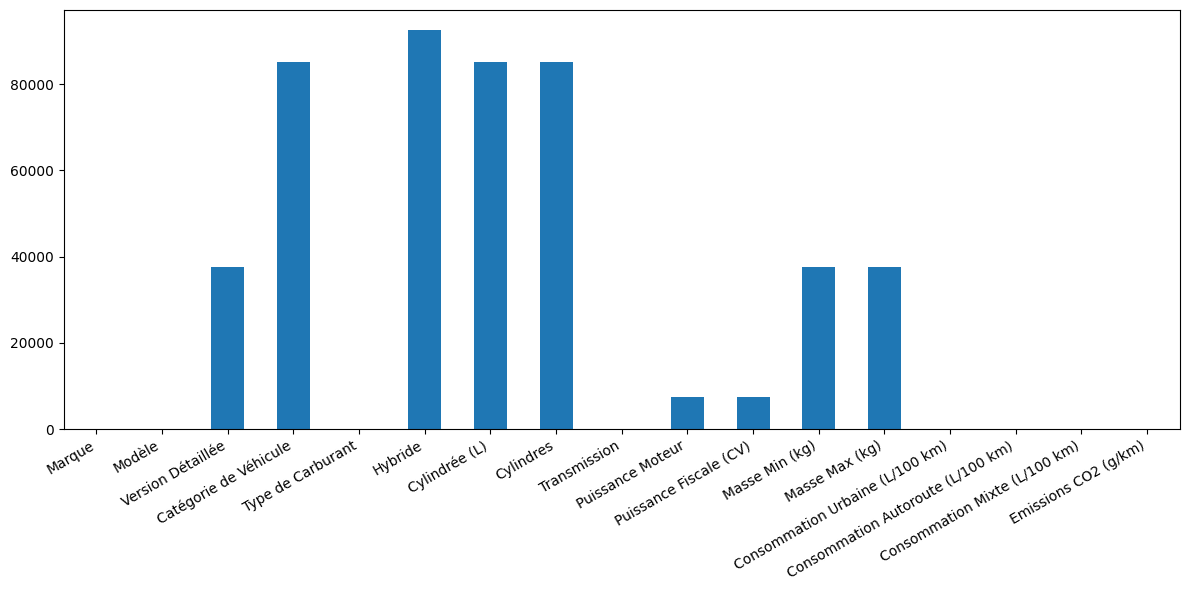

In [312]:
plt.figure(figsize=(12,6))
df.isnull().sum().plot(kind='bar')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Analyse Statistique Des Données

<Figure size 2000x1000 with 0 Axes>

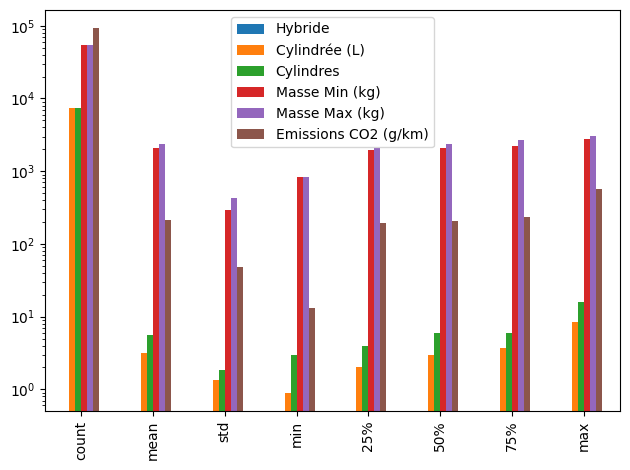

In [313]:
plt.figure(figsize=(20,10))
df.describe().plot(kind='bar', logy=True)
plt.tight_layout()
plt.show()


La Distribution Des Données

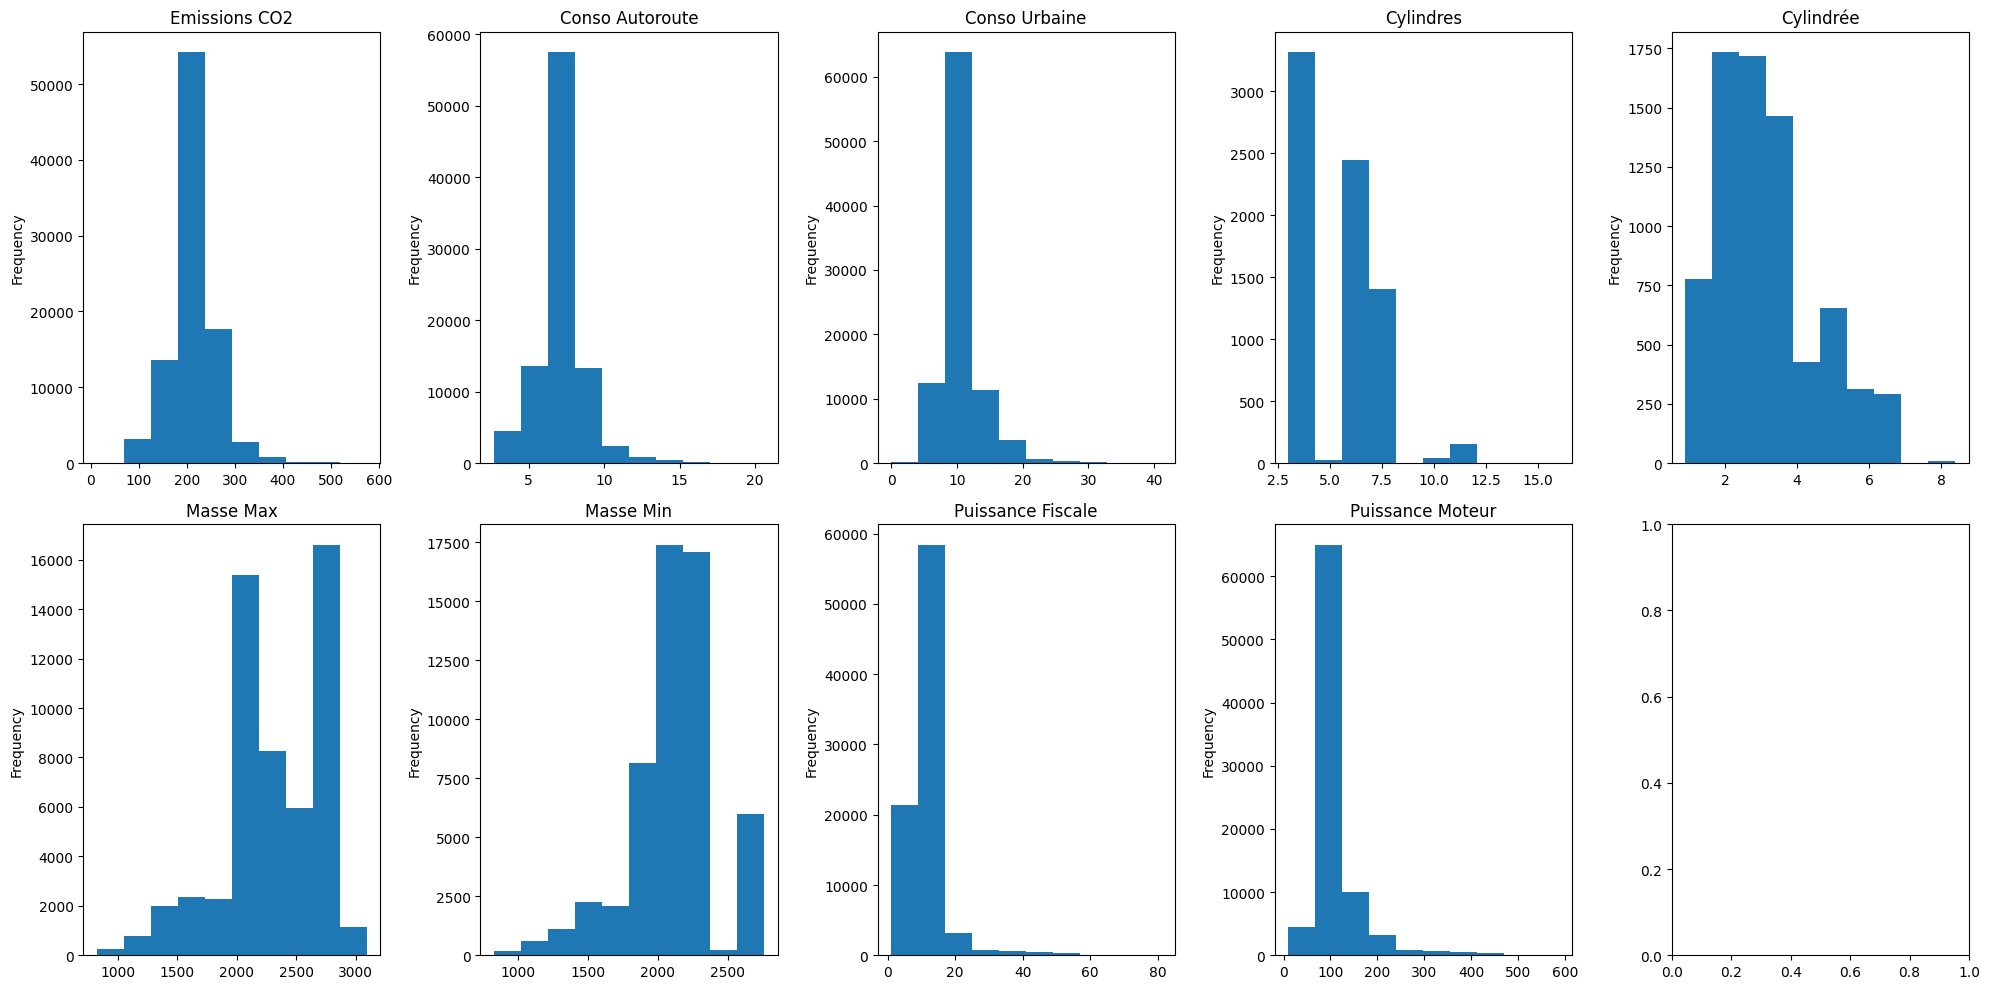

In [314]:
# Tout d'abord Assurez vous d'avoir convertit les colonnes string en numerique
cols_a_corriger = [
    'Consommation Autoroute (L/100 km)', 
    'Consommation Urbaine (L/100 km)',
    'Puissance Fiscale (CV)',
    'Puissance Moteur',
    # Ajoute d'autres colonnes ici si elles plantent aussi (ex: Consommation Mixte)
]

for col in cols_a_corriger:
    # 1. Si tu as des virgules (format français "5,5"), on les remplace par des points
    # Si tes chiffres sont déjà avec des points, cette ligne ne fera rien de mal.
    df[col] = df[col].astype(str).str.replace(',', '.')
    
    # 2. On force la conversion en numérique. 
    # 'coerce' va transformer les erreurs (texte bizarre) en NaN (vide) pour ne pas bloquer le code
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 1. On crée d'abord la grille (2 lignes, 5 colonnes pour tes 9 graphiques)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 10))

# 2. On dessine dans chaque case spécifique (axes[ligne, colonne])
df['Emissions CO2 (g/km)'].plot(kind='hist', ax=axes[0,0], title='Emissions CO2')
df['Consommation Autoroute (L/100 km)'].plot(kind='hist', ax=axes[0,1], title='Conso Autoroute')
df['Consommation Urbaine (L/100 km)'].plot(kind='hist', ax=axes[0,2], title='Conso Urbaine')
df['Cylindres'].plot(kind='hist', ax=axes[0,3], title='Cylindres')
df['Cylindrée (L)'].plot(kind='hist', ax=axes[0,4], title='Cylindrée')

df['Masse Max (kg)'].plot(kind='hist', ax=axes[1,0], title='Masse Max')
df['Masse Min (kg)'].plot(kind='hist', ax=axes[1,1], title='Masse Min')
df['Puissance Fiscale (CV)'].plot(kind='hist', ax=axes[1,2], title='Puissance Fiscale')
df['Puissance Moteur'].plot(kind='hist', ax=axes[1,3], title='Puissance Moteur')
#df['Age_Vehicule'].plot(kind='hist', ax=axes[1,4], title='Age_Vehicule')


# 4. Pour éviter que les titres se chevauchent
plt.tight_layout()
plt.show()

Matrice de correlation

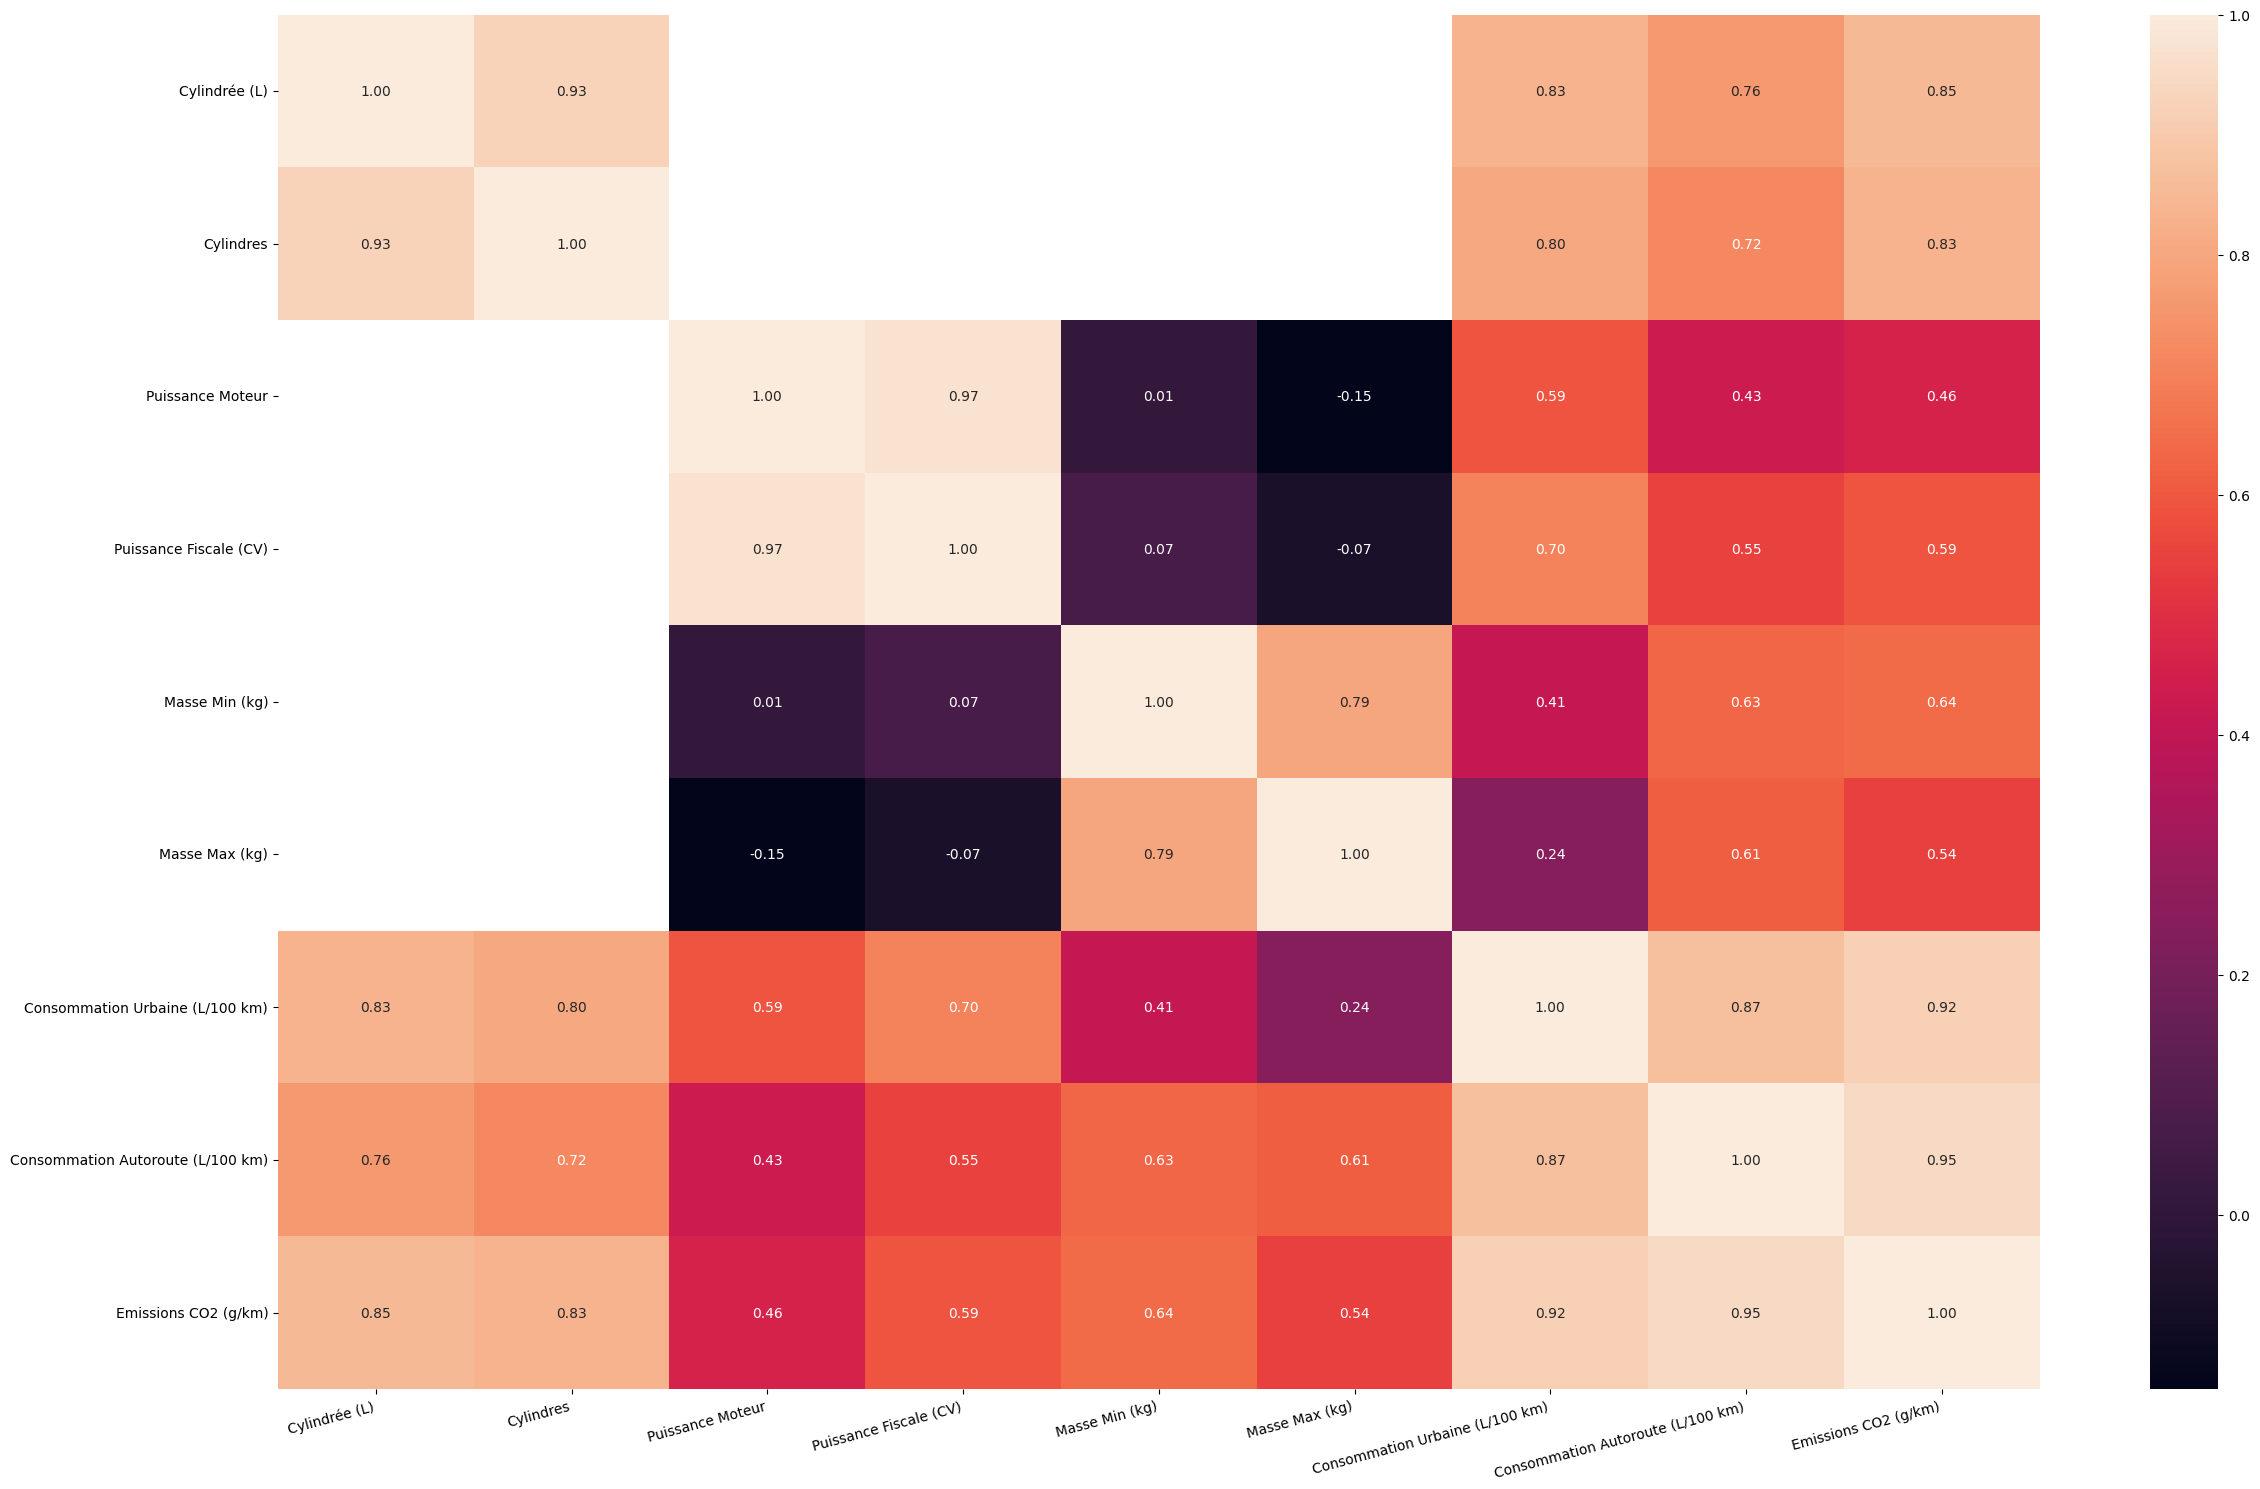

In [315]:
# 1. On sélectionne les nombres
df_num = df.select_dtypes('number')

# 2. On supprime les colonnes où la variance est nulle (valeurs constantes)
# On ne garde que les colonnes où l'écart-type (std) est > 0
df_num = df_num.loc[:, df_num.std() > 0]

# 3. Calcul de la corrélation
corr = df_num.corr()

# 4. Affichage
plt.figure(figsize=(25,15))
sns.heatmap(corr, annot=True, cmap='rocket', fmt=".2f") # j'ai ajouté fmt=".2f" pour la lisibilité
#plt.title("Matrice de Corrélation (Variables constantes exclues)")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

10 Marques de vehicule plus polluant vs les 10 plus propres

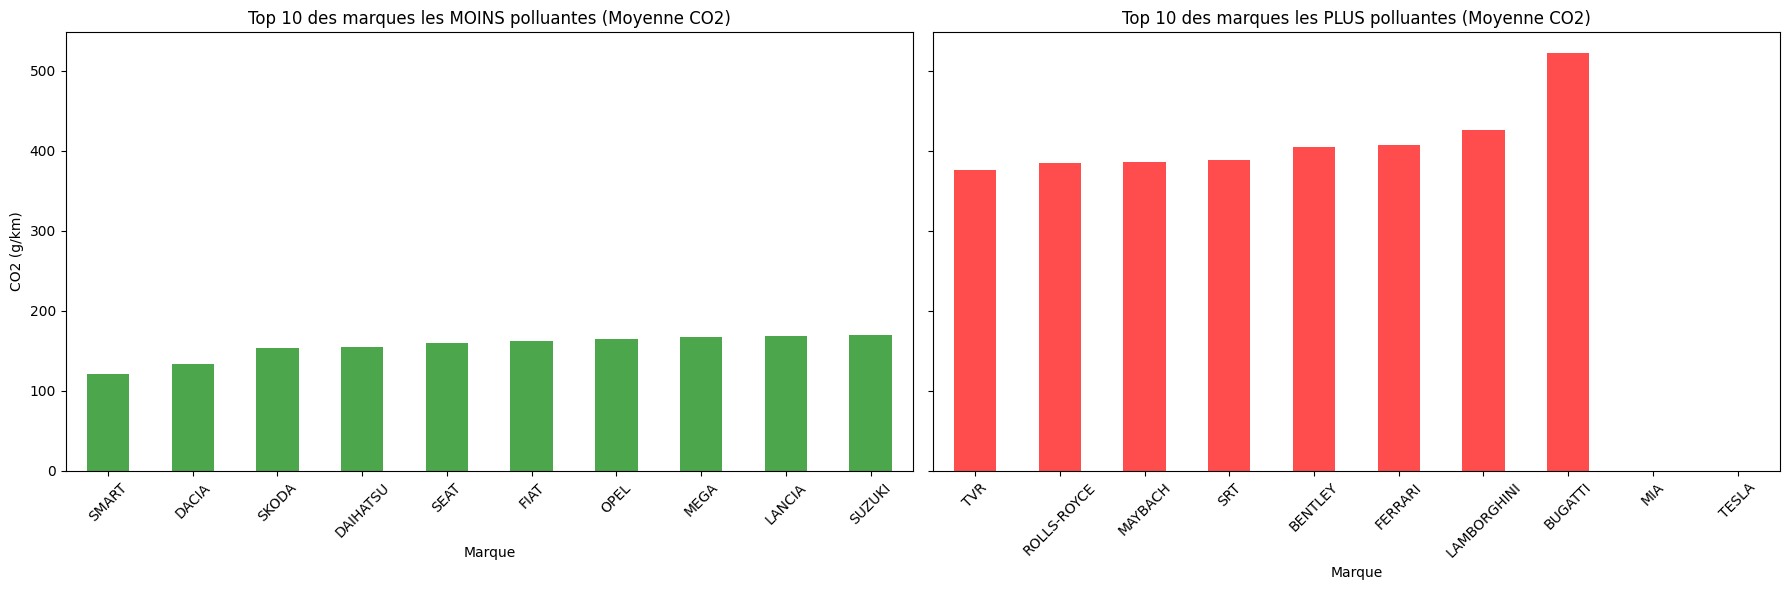

In [316]:
# Calcul de la moyenne par marque
colonne_marque = 'Marque'
co2_par_marque = df.groupby(colonne_marque)['Emissions CO2 (g/km)'].mean().sort_values()

# On prend les 10 premiers (les plus propres) et les 10 derniers (les plus sales)
top_10_clean = co2_par_marque.head(10)
top_10_dirty = co2_par_marque.tail(10)

# Création du graphique double
fig, axes = plt.subplots(1, 2, figsize=(18, 6),sharey=True)

# Graphique 1 : Les bons élèves
top_10_clean.plot(kind='bar', ax=axes[0], color='green', alpha=0.7)
axes[0].set_title('Top 10 des marques les MOINS polluantes (Moyenne CO2)')
axes[0].set_ylabel('CO2 (g/km)')
axes[0].tick_params(axis='x', rotation=45)

# Graphique 2 : Les mauvais élèves
top_10_dirty.plot(kind='bar', ax=axes[1], color='red', alpha=0.7)
axes[1].set_title('Top 10 des marques les PLUS polluantes (Moyenne CO2)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Nettoyage Des Données

Gestion Des Valeurs Manquantes

In [317]:
df.isnull()

,Marque,Modèle,Version Détaillée,Catégorie de Véhicule,Type de Carburant,Hybride,Cylindrée (L),Cylindres,Transmission,Puissance Moteur,Puissance Fiscale (CV),Masse Min (kg),Masse Max (kg),Consommation Urbaine (L/100 km),Consommation Autoroute (L/100 km),Consommation Mixte (L/100 km),Emissions CO2 (g/km)
0,False,False,True,False,False,True,False,False,False,True,True,True,True,False,False,False,False
1,False,False,True,False,False,True,False,False,False,True,True,True,True,False,False,False,False
2,False,False,True,False,False,True,False,False,False,True,True,True,True,False,False,False,False
3,False,False,True,False,False,True,False,False,False,True,True,True,True,False,False,False,False
4,False,False,True,False,False,True,False,False,False,True,True,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92590,False,False,True,True,False,True,True,True,False,False,False,True,True,False,False,False,False
92591,False,False,True,True,False,True,True,True,False,False,False,True,True,False,False,False,False
92592,False,False,True,True,False,True,True,True,False,False,False,True,True,False,False,False,False
92593,False,False,True,True,False,True,True,True,False,False,False,True,True,False,False,False,False


Suppresion Des Doublons

In [318]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

64485
0


In [319]:
df.isnull().sum() 

Marque                                   0
Modèle                                   0
Version Détaillée                    20869
Catégorie de Véhicule                21829
Type de Carburant                        0
Hybride                              28110
Cylindrée (L)                        21829
Cylindres                            21829
Transmission                             0
Puissance Moteur                      6281
Puissance Fiscale (CV)                6331
Masse Min (kg)                       20869
Masse Max (kg)                       20869
Consommation Urbaine (L/100 km)         37
Consommation Autoroute (L/100 km)       37
Consommation Mixte (L/100 km)           29
Emissions CO2 (g/km)                    29
dtype: int64

Inputation par la mediane

In [320]:
def nettoyage_valeur(valeur):
    if pd.isna(valeur):
        return np.nan
    
    if isinstance(valeur, (int, float)):
        return float(valeur)
    
    if isinstance(valeur, str):
        valeur = valeur.strip()
        
        if valeur == '':
            return np.nan
        
        valeur = valeur.replace(',', '.')
        
        try:
            return float(valeur)
        except ValueError:
            return np.nan
    
    return np.nan

# Les colonnes à nettoyer
colonnes_a_nettoyer = ['Puissance Moteur', 'Puissance Fiscale (CV)','Emissions CO2 (g/km)','Consommation Mixte (L/100 km)','Consommation Autoroute (L/100 km)','Consommation Urbaine (L/100 km)','Cylindres','Cylindrée (L)','Masse Min (kg)','Masse Max (kg)']

# Nettoyage des colonnes
for col in colonnes_a_nettoyer:
    
    # Étape 1 : Nettoyage
    df[col] = df[col].apply(nettoyage_valeur)
    
    # Étape 2 : Conversion en numérique 
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Étape 3 : Remplissage des NaN avec la médiane
    mediane = df[col].median()
    
    # --- CORRECTION ICI ---
    # On assigne le résultat de fillna() à la colonne. On retire "inplace=True".
    df[col] = df[col].fillna(mediane)
    # ----------------------
    
    print(f"{col} - Médiane utilisée : {mediane}")

# Vérification du résultat
print("\nInfo après nettoyage :")
print(df[colonnes_a_nettoyer].info())
print("\nStatistiques :")
print(df[colonnes_a_nettoyer].describe())

Puissance Moteur - Médiane utilisée : 100.0
Puissance Fiscale (CV) - Médiane utilisée : 9.0
Emissions CO2 (g/km) - Médiane utilisée : 201.0
Consommation Mixte (L/100 km) - Médiane utilisée : 8.100000381
Consommation Autoroute (L/100 km) - Médiane utilisée : 6.7
Consommation Urbaine (L/100 km) - Médiane utilisée : 10.3
Cylindres - Médiane utilisée : 6.0
Cylindrée (L) - Médiane utilisée : 3.0
Masse Min (kg) - Médiane utilisée : 1761.0
Masse Max (kg) - Médiane utilisée : 1785.0

Info après nettoyage :
<class 'pandas.core.frame.DataFrame'>
Index: 28110 entries, 0 to 92594
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Puissance Moteur                   28110 non-null  float64
 1   Puissance Fiscale (CV)             28110 non-null  float64
 2   Emissions CO2 (g/km)               28110 non-null  float64
 3   Consommation Mixte (L/100 km)      28110 non-null  float64
 4   Con

gestion des valeurs categorielles avec des techniques backward fill et forward fill

1-Nettoyage des colonnes Type Carburant et Hybride

In [321]:
correction_energie = {
    # --- DIESEL ---
    'GO': 'Diesel',       # Gazole (Standard)
    'D': 'Diesel',        # Vieux code pour Diesel
    
    # --- ESSENCE ---
    'ES': 'Essence',      # Essence (Standard)
    
    # --- HYBRIDES (Crucial pour le CO2) ---
    'EH': 'Essence-Electricité',      # Essence-Electricité (Non rechargeable)
    'EE': 'Essence-Electricité',      # Essence-Electricité (Rechargeable)
    'GH': 'Gazole-Electricité',      # Gazole-Electricité (Hybride Diesel)
    'GL': 'Gazole-Electricité',      # Gazole-Electricité (Rechargeable)
    
    # --- ÉLECTRIQUE ---
    'EL': 'Electrique',   # Electricité
    'E': 'Electrique',    # Vieux code Electrique
    'NE': 'Electrique',   # (Souvent utilisé pour elec, à vérifier)
    
    # --- GAZ & BIOETHANOL (Moins polluants) ---
    'FE': 'Ethanol',      # Superéthanol E85
    'GP': 'GPL',          # Gaz de Pétrole Liquéfié
    'ES/GP': 'GPL',       # Bi-carburation Essence/GPL
    'GP/ES': 'GPL',       # Idem
    'GN': 'GNV',          # Gaz Naturel Véhicule
    'EN': 'GNV',          # Essence-Gaz Naturel (Code rare)
    'ES/GN': 'GNV',       # Bi-carburation
    'GN/ES': 'GNV',       # Idem
    'GN/GS': 'GNV',       # Variante GNV
    
    # --- AUTRES / INCONNUS ---
    # Ces codes sont souvent des erreurs ou des prototypes.
    # Pour un modèle, mieux vaut souvent les mettre en 'Essence' par défaut ou les supprimer.
    'Z': 'Autre',
    'X': 'Autre',
    'N': 'Autre'
}

# 1. On applique le mapping
df['Type de Carburant'].replace(correction_energie,inplace=True)
df['Hybride'] = np.where(df['Type de Carburant'].str.contains('-'),'oui','non')


C:\Users\pc\AppData\Local\Temp\ipykernel_38904\3062540952.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Type de Carburant'].replace(correction_energie,inplace=True)


2-Backward fill et forward fill

In [322]:
df['Version Détaillée'].fillna(method='bfill',inplace=True)
df['Version Détaillée'].fillna(method='ffill',inplace=True)
df['Catégorie de Véhicule'].fillna(method='bfill', inplace=True)
df['Catégorie de Véhicule'].fillna(method='ffill', inplace=True)
df['Hybride'].fillna(method='ffill', inplace=True)
df['Hybride'].fillna(method='bfill', inplace=True)

C:\Users\pc\AppData\Local\Temp\ipykernel_38904\3480047038.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Version Détaillée'].fillna(method='bfill',inplace=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_38904\3480047038.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Version Détaillée'].fillna(method='bfill',inplace=True)
C:\Users\pc\AppData\Local\Temp\ipykernel_38904\3480047038.py:2: FutureWarning: Series.fillna with 'meth

Ajout d'une dimension temporelle

In [323]:
# 1. On définit les bornes de tes émissions CO2 (basées sur tes stats ou calculées dynamiquement)
co2_min = df['Emissions CO2 (g/km)'].min() # Devrait être 129
co2_max = df['Emissions CO2 (g/km)'].max() # Devrait être 297

# 2. On définit la plage d'âge cible
age_min = 1
age_max = 10

# 3. On applique la formule de transformation linéaire
# Formule : (Valeur - Min) / (Max - Min) donne un % entre 0 et 1.
# On multiplie ensuite par l'écart d'âge (9) et on ajoute l'âge de départ (1).

df['Age_Vehicule'] = (
    (df['Emissions CO2 (g/km)'] - co2_min) / (co2_max - co2_min)
) * (age_max - age_min) + age_min


#Ajout du bruit pour diminuer la forte corellation
# On ajoute un bruit aléatoire (loi normale) : moyenne 0, écart-type 1.5 an
# Cela signifie qu'on décale l'âge un peu au hasard de +/- 1 ou 2 ans
bruit = np.random.normal(loc=0, scale=1.5, size=len(df))
df['Age_Vehicule'] = df['Age_Vehicule'] + bruit

# 4. On arrondit pour avoir des nombres entiers (optionnel mais logique pour un âge)
df['Age_Vehicule'] = df['Age_Vehicule'].round().astype(int)

# Vérification
df[['Emissions CO2 (g/km)', 'Age_Vehicule']].head()

,Emissions CO2 (g/km),Age_Vehicule
0,196.0,3
1,221.0,2
2,136.0,7
3,255.0,5
4,244.0,6


Suppression des colonnes unitiles

In [324]:
# --- CORRECTION : Suppression des colonnes textes inutilisables ---
colonnes_textes_a_supprimer = ['Modèle', 'Version Détaillée','Consommation Mixte (L/100 km)']

# On supprime ces colonnes du DataFrame car on ne peut pas les donner au modèle
df = df.drop(columns=colonnes_textes_a_supprimer, errors='ignore')

print("Colonnes supprimées. Nouvelles colonnes du DataFrame :")
print(df.columns.tolist())

Colonnes supprimées. Nouvelles colonnes du DataFrame :
['Marque', 'Catégorie de Véhicule', 'Type de Carburant', 'Hybride', 'Cylindrée (L)', 'Cylindres', 'Transmission', 'Puissance Moteur', 'Puissance Fiscale (CV)', 'Masse Min (kg)', 'Masse Max (kg)', 'Consommation Urbaine (L/100 km)', 'Consommation Autoroute (L/100 km)', 'Emissions CO2 (g/km)', 'Age_Vehicule']


Verification

In [325]:
df.isnull().sum()

Marque                               0
Catégorie de Véhicule                0
Type de Carburant                    0
Hybride                              0
Cylindrée (L)                        0
Cylindres                            0
Transmission                         0
Puissance Moteur                     0
Puissance Fiscale (CV)               0
Masse Min (kg)                       0
Masse Max (kg)                       0
Consommation Urbaine (L/100 km)      0
Consommation Autoroute (L/100 km)    0
Emissions CO2 (g/km)                 0
Age_Vehicule                         0
dtype: int64

Encodage

1- Verification initiale

In [326]:
# Supprimer colonne Version Détaillée (trop de catégories / redondant)
if 'Version Détaillée' in df.columns:
    df = df.drop(columns=['Version Détaillée'])

# Définir colonnes catégorielles
cat_cols = ['Marque', 'Catégorie de Véhicule', 'Type de Carburant', 'Hybride', 'Transmission']

# Afficher nombre de catégories par colonne
for col in cat_cols:
    print(f"{col} : {df[col].nunique()} catégories")


Marque : 79 catégories
Catégorie de Véhicule : 16 catégories
Type de Carburant : 9 catégories
Hybride : 2 catégories
Transmission : 49 catégories


Nettoyage de la colonne Transmission

In [327]:
def clean_transmission(x):
    if pd.isna(x):
        return x
    s = str(x).upper().strip()
    s = re.sub(r'\s+', ' ', s)  # remplacer multiples espaces par un seul
    s = re.sub(r'[^A-Z0-9 \-]', '', s)  # enlever caractères non alphanumériques sauf espace et -
    return s

df['Transmission'] = df['Transmission'].apply(clean_transmission)
print("Unique transmissions (exemples) :", df['Transmission'].dropna().unique()[:30])


Unique transmissions (exemples) : ['AS5' 'M6' 'AV7' 'AS6' 'AM6' 'A6' 'AM7' 'AV8' 'AS8' 'A7' 'A8' 'M7' 'A4'
 'M5' 'AV' 'A5' 'AS7' 'A9' 'AS9' 'AV6' 'AS4' 'AM5' 'AM8' 'AM9' 'AS10'
 'A10' 'AV10' 'M 6' 'A 6' 'D 6']


Definition des encodeurs

In [328]:
# Colonnes pour OneHotEncoder (cardinalité raisonnable)
ohe_cols = ['Marque', 'Catégorie de Véhicule', 'Type de Carburant', 'Hybride', 'Transmission']

# OneHotEncoder et OrdinalEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


Column Transformer , fit et transformation

In [329]:
ct = ColumnTransformer(
    transformers=[
        ('ohe', ohe, ohe_cols)
    ],
    remainder='passthrough'  # garde les colonnes numériques
)

# Colonnes numériques restantes
num_cols = [c for c in df.columns if c not in ohe_cols ]
print("Colonnes numériques restantes :", num_cols)

ct.fit(df)
arr = ct.transform(df)



Colonnes numériques restantes : ['Cylindrée (L)', 'Cylindres', 'Puissance Moteur', 'Puissance Fiscale (CV)', 'Masse Min (kg)', 'Masse Max (kg)', 'Consommation Urbaine (L/100 km)', 'Consommation Autoroute (L/100 km)', 'Emissions CO2 (g/km)', 'Age_Vehicule']


Reconctruction du dataframe

In [330]:
# Récupérer noms des colonnes
try:
    feature_names = ct.get_feature_names_out()
except Exception:
    ohe_names = ohe.get_feature_names_out(ohe_cols)
    feature_names = list(ohe_names) + num_cols

# DataFrame final encodé
df_encoded = pd.DataFrame(arr, columns=feature_names, index=df.index)



# Résultats
print("Shape before:", df.shape)
print("Shape after encoding:", df_encoded.shape)
display(df_encoded.head())


Shape before: (28110, 15)
Shape after encoding: (28110, 165)


,ohe__Marque_ACURA,ohe__Marque_ALFA ROMEO,ohe__Marque_ALFA-ROMEO,ohe__Marque_ASTON MARTIN,ohe__Marque_AUDI,ohe__Marque_BENTLEY,ohe__Marque_BMW,ohe__Marque_BUGATTI,ohe__Marque_BUICK,ohe__Marque_CADILLAC,...,remainder__Cylindrée (L),remainder__Cylindres,remainder__Puissance Moteur,remainder__Puissance Fiscale (CV),remainder__Masse Min (kg),remainder__Masse Max (kg),remainder__Consommation Urbaine (L/100 km),remainder__Consommation Autoroute (L/100 km),remainder__Emissions CO2 (g/km),remainder__Age_Vehicule
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,4.0,100.0,9.0,1761.0,1785.0,9.9,6.7,196.0,3.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.4,4.0,100.0,9.0,1761.0,1785.0,11.2,7.7,221.0,2.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.5,4.0,100.0,9.0,1761.0,1785.0,6.0,5.8,136.0,7.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.5,6.0,100.0,9.0,1761.0,1785.0,12.7,9.1,255.0,5.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.5,6.0,100.0,9.0,1761.0,1785.0,12.1,8.7,244.0,6.0


Sauvegarde et Suppression

In [331]:
# Sauvegarder le DataFrame final encodé dans un fichier CSV
df_encoded.to_csv("dataset_final.csv", index=False)
print("Dataset encodé sauvegardé dans 'dataset_final.csv'")

fichier_a_supprimer = "CO2_Emissions_Global_Dataset.csv"

try:
    os.remove(fichier_a_supprimer)
    print(f"Le fichier '{fichier_a_supprimer}' a été supprimé.")
except FileNotFoundError:
    print(f"Le fichier '{fichier_a_supprimer}' n'existait pas (rien à faire).")
except PermissionError:
    print(f"Erreur : Vous n'avez pas la permission de supprimer '{fichier_a_supprimer}'.")


Dataset encodé sauvegardé dans 'dataset_final.csv'
Le fichier 'CO2_Emissions_Global_Dataset.csv' a été supprimé.


Lecture du neauveau data set

In [332]:
dataframe = pd.read_csv('dataset_final.csv')
dataframe.drop_duplicates(inplace=True)
if 'Unnamed: 0' in dataframe.columns:
    dataframe.drop('Unnamed: 0', axis=1, inplace=True)
dataframe.head()

,ohe__Marque_ACURA,ohe__Marque_ALFA ROMEO,ohe__Marque_ALFA-ROMEO,ohe__Marque_ASTON MARTIN,ohe__Marque_AUDI,ohe__Marque_BENTLEY,ohe__Marque_BMW,ohe__Marque_BUGATTI,ohe__Marque_BUICK,ohe__Marque_CADILLAC,...,remainder__Cylindrée (L),remainder__Cylindres,remainder__Puissance Moteur,remainder__Puissance Fiscale (CV),remainder__Masse Min (kg),remainder__Masse Max (kg),remainder__Consommation Urbaine (L/100 km),remainder__Consommation Autoroute (L/100 km),remainder__Emissions CO2 (g/km),remainder__Age_Vehicule
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,4.0,100.0,9.0,1761.0,1785.0,9.9,6.7,196.0,3.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.4,4.0,100.0,9.0,1761.0,1785.0,11.2,7.7,221.0,2.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.5,4.0,100.0,9.0,1761.0,1785.0,6.0,5.8,136.0,7.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.5,6.0,100.0,9.0,1761.0,1785.0,12.7,9.1,255.0,5.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.5,6.0,100.0,9.0,1761.0,1785.0,12.1,8.7,244.0,6.0


Entrainement Des Modèles

1-Separation Des Données (train,test,validation)

In [333]:
X = dataframe.drop('remainder__Emissions CO2 (g/km)',axis=1)
y = dataframe['remainder__Emissions CO2 (g/km)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.166, random_state=42)
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Vérification des tailles
print(f"Entraînement : {X_train.shape[0]} lignes")
print(f"Test         : {X_test.shape[0]} lignes")
print(f"Validation         : {X_validation.shape[0]} lignes")

Entraînement : 16659 lignes
Test         : 4146 lignes
Validation         : 4165 lignes


Modèle XGBoost

In [334]:
# Entrainement 
model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    tree_method="hist" ,
    enable_categorical=False  # Important
)

model_xgb.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


prediction

In [335]:
y_train_pred_xg = model_xgb.predict(X_train)
y_test_pred_xg = model_xgb.predict(X_test)
y_valid_pred_xg = model_xgb.predict(X_validation)

Performance

In [336]:
train_mse_xg = mean_squared_error(y_train, y_train_pred_xg)
test_mse_xg = mean_squared_error(y_test, y_test_pred_xg)
valid_mse_xg = mean_squared_error(y_validation,y_valid_pred_xg)

train_rmse_xg = np.sqrt(train_mse_xg)
test_rmse_xg = np.sqrt(test_mse_xg)
valid_rmse_xg = np.sqrt(valid_mse_xg)

train_mae_xg = mean_absolute_error(y_train, y_train_pred_xg)
test_mae_xg = mean_absolute_error(y_test, y_test_pred_xg)
valid_mae_xg = mean_absolute_error(y_validation,y_valid_pred_xg)

train_r2_xg = r2_score(y_train, y_train_pred_xg)
test_r2_xg = r2_score(y_test, y_test_pred_xg)
valid_r2_xg = r2_score(y_validation,y_valid_pred_xg)

performance_table = pd.DataFrame({
    'Métrique': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Ensemble d\'entraînement': [train_mse_xg, train_rmse_xg, train_mae_xg, train_r2_xg],
    'Ensemble de test': [test_mse_xg, test_rmse_xg, test_mae_xg, test_r2_xg],
    'Ensemble de validation': [valid_mse_xg, valid_rmse_xg, valid_mae_xg, valid_r2_xg]
})

print(performance_table)


  Métrique  Ensemble d'entraînement  Ensemble de test  Ensemble de validation
0      MSE                 1.788575         15.529172               10.043375
1     RMSE                 1.337376          3.940707                3.169128
2      MAE                 0.975504          1.625349                1.573494
3       R²                 0.999541          0.996057                0.997389


Erreur Test

In [337]:
erreurs = pd.DataFrame({
    "Réel": y_test,
    "Pred": y_test_pred_xg,
    "Erreur": abs(y_test - y_test_pred_xg)
}).sort_values("Erreur", ascending=False)

erreurs.head(5)


,Réel,Pred,Erreur
8390,244.0,340.730469,96.730469
8386,246.0,342.710449,96.710449
8392,225.0,316.832031,91.832031
13492,48.0,120.270096,72.270096
23385,161.0,201.057190,40.057190


In [338]:
erreurs = pd.DataFrame({
    "Réel": y_validation,
    "Pred": y_valid_pred_xg,
    "Erreur": abs(y_validation - y_valid_pred_xg)
}).sort_values("Erreur", ascending=False)

erreurs.head(5)


,Réel,Pred,Erreur
2232,213.0,289.130280,76.130280
21441,499.0,454.037598,44.962402
351,382.0,420.708618,38.708618
11403,121.0,159.638031,38.638031
23387,162.0,199.932587,37.932587


Random Forest

In [339]:
model_random_forest = RandomForestRegressor(n_estimators=500,criterion='friedman_mse',max_depth=None,min_samples_split=4,min_samples_leaf=2,bootstrap=True,max_features='sqrt')
model_random_forest.fit(X_train,y_train)

y_train_pred_rf = model_random_forest.predict(X_train)
y_test_pred_rf = model_random_forest.predict(X_test)
y_valid_pred_rf = model_random_forest.predict(X_validation)

Performance

In [340]:
# 2. Calculer les métriques d'erreur
train_mse_rf = mean_squared_error(y_train, y_train_pred_rf)
test_mse_rf = mean_squared_error(y_test, y_test_pred_rf)
valid_mse_rf = mean_squared_error(y_validation,y_valid_pred_rf)

train_rmse_rf = np.sqrt(train_mse_rf)
test_rmse_rf = np.sqrt(test_mse_rf)
valid_rmse_rf = np.sqrt(valid_mse_rf)

train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
test_mae_rf = mean_absolute_error(y_test, y_test_pred_rf)
valid_mae_rf = mean_absolute_error(y_validation,y_valid_pred_rf)

train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)
valid_r2_rf = r2_score(y_validation, y_valid_pred_rf)

performance_table = pd.DataFrame({
    'Métrique': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Ensemble d\'entraînement': [train_mse_rf, train_rmse_rf, train_mae_rf, train_r2_rf],
    'Ensemble de test': [test_mse_rf, test_rmse_rf, test_mae_rf, test_r2_rf],
    'Ensemble de validation': [valid_mse_rf, valid_rmse_rf, valid_mae_rf, valid_r2_rf]
})

print(performance_table)


  Métrique  Ensemble d'entraînement  Ensemble de test  Ensemble de validation
0      MSE                39.036714         65.082851               57.899053
1     RMSE                 6.247937          8.067394                7.609143
2      MAE                 3.828203          4.626713                4.580876
3       R²                 0.989974          0.983475                0.984948


Erreur Test

In [341]:
erreurs = pd.DataFrame({
    "Réel": y_test,
    "Pred": y_test_pred_rf,
    "Erreur": abs(y_test - y_test_pred_rf)
}).sort_values("Erreur", ascending=False)

erreurs.head()

,Réel,Pred,Erreur
16345,570.0,440.890289,129.109711
16344,558.0,458.541192,99.458808
13492,48.0,136.887717,88.887717
24959,575.0,487.393484,87.606516
4583,473.0,395.656902,77.343098


Erreur Validation

In [342]:
erreurs = pd.DataFrame({
    "Réel": y_validation,
    "Pred": y_valid_pred_rf,
    "Erreur": abs(y_validation - y_valid_pred_rf)
}).sort_values("Erreur", ascending=False)

erreurs.head()

,Réel,Pred,Erreur
4199,522.0,433.869309,88.130691
7186,13.0,100.081744,87.081744
349,488.0,401.945063,86.054937
24963,575.0,495.414879,79.585121
21441,499.0,424.360614,74.639386


Decision Tree

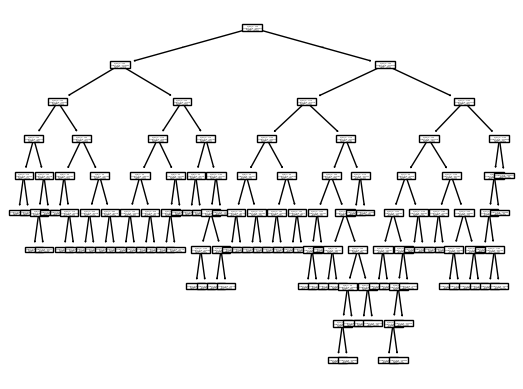

In [343]:
model_tree = DecisionTreeRegressor(criterion='friedman_mse',max_depth=11,splitter='best',min_samples_leaf=50,max_leaf_nodes=65,min_samples_split=100,ccp_alpha=0)
model_tree.fit(X_train,y_train)
tree.plot_tree(model_tree)
plt.show()

In [344]:
y_train_pred_t = model_tree.predict(X_train)
y_test_pred_t = model_tree.predict(X_test)
y_valid_pred_t = model_tree.predict(X_validation)

# 2. Calculer les métriques d'erreur
train_mse_t = mean_squared_error(y_train, y_train_pred_t)
test_mse_t = mean_squared_error(y_test, y_test_pred_t)
valid_mse_t = mean_squared_error(y_validation, y_valid_pred_t)


train_rmse_t = np.sqrt(train_mse_t)
test_rmse_t = np.sqrt(test_mse_t)
valid_rmse_t = np.sqrt(valid_mse_t)

train_mae_t = mean_absolute_error(y_train, y_train_pred_t)
test_mae_t = mean_absolute_error(y_test, y_test_pred_t)
valid_mae_t = mean_absolute_error(y_validation, y_valid_pred_t)

train_r2_t = r2_score(y_train, y_train_pred_t)
test_r2_t = r2_score(y_test, y_test_pred_t)
valid_r2_t = r2_score(y_validation, y_valid_pred_t)

performance_table = pd.DataFrame({
    'Métrique': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Ensemble d\'entraînement': [train_mse_t, train_rmse_t, train_mae_t, train_r2_t],
    'Ensemble de test': [test_mse_t, test_rmse_t, test_mae_t, test_r2_t],
    'Ensemble de validation': [valid_mse_t, valid_rmse_t, valid_mae_t, valid_r2_t]
})

print(performance_table)


  Métrique  Ensemble d'entraînement  Ensemble de test  Ensemble de validation
0      MSE               113.643644        123.974571              124.029327
1     RMSE                10.660377         11.134387               11.136845
2      MAE                 6.701726          6.895516                6.803595
3       R²                 0.970813          0.968521                0.967756


Modèle Mlp

In [345]:
model_mlp = MLPRegressor(
    hidden_layer_sizes=(32, 16),   # réseau léger
    activation='relu',
    solver='adam',
    max_iter=200,                  # réduit pour la vitesse
    early_stopping=True,           # arrêt automatique
    n_iter_no_change=10,
    learning_rate_init=0.001,
    random_state=42
)
model_mlp.fit(X_train, y_train)


,loss,'squared_error'
,hidden_layer_sizes,"(32, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True


In [346]:
y_train_pred_mlp = model_mlp.predict(X_train)
y_test_pred_mlp = model_mlp.predict(X_test)
y_valid_pred_mlp = model_mlp.predict(X_validation)

# 2. Calculer les métriques d'erreur
train_mse_mlp = mean_squared_error(y_train, y_train_pred_mlp)
test_mse_mlp = mean_squared_error(y_test, y_test_pred_mlp)
valid_mse_mlp = mean_squared_error(y_validation, y_valid_pred_mlp)

train_rmse_mlp = np.sqrt(train_mse_mlp)
test_rmse_mlp = np.sqrt(test_mse_mlp)
valid_rmse_mlp = np.sqrt(valid_mse_mlp)

train_mae_mlp = mean_absolute_error(y_train, y_train_pred_mlp)
test_mae_mlp = mean_absolute_error(y_test, y_test_pred_mlp)
valid_mae_mlp = mean_absolute_error(y_validation, y_valid_pred_mlp)

train_r2_mlp = r2_score(y_train, y_train_pred_mlp)
test_r2_mlp = r2_score(y_test, y_test_pred_mlp)
valid_r2_mlp = r2_score(y_validation, y_valid_pred_mlp)

performance_table = pd.DataFrame({
    'Métrique': ['MSE', 'RMSE', 'MAE', 'R²'],
    'Ensemble d\'entraînement': [train_mse_mlp, train_rmse_mlp, train_mae_mlp, train_r2_mlp],
    'Ensemble de test': [test_mse_mlp, test_rmse_mlp, test_mae_mlp, test_r2_mlp],
    'Ensemble de validation': [valid_mse_mlp, valid_rmse_mlp, valid_mae_mlp, valid_r2_mlp]
})

print(performance_table)


  Métrique  Ensemble d'entraînement  Ensemble de test  Ensemble de validation
0      MSE                38.932847         45.501667               41.259501
1     RMSE                 6.239619          6.745492                6.423356
2      MAE                 3.382916          3.487919                3.409636
3       R²                 0.990001          0.988446                0.989274


Erreur Test

In [347]:
erreurs = pd.DataFrame({
    "Réel": y_test,
    "Pred": y_test_pred_mlp,
    "Erreur": abs(y_test - y_test_pred_mlp)
}).sort_values("Erreur", ascending=False)

erreurs.head()

,Réel,Pred,Erreur
8386,246.0,348.404587,102.404587
8390,244.0,346.042259,102.042259
8392,225.0,317.146093,92.146093
11622,201.0,124.723993,76.276007
12231,201.0,126.472733,74.527267


Erreur Validation

In [348]:
erreurs = pd.DataFrame({
    "Réel": y_validation,
    "Pred": y_valid_pred_mlp,
    "Erreur": abs(y_validation - y_valid_pred_mlp)
}).sort_values("Erreur", ascending=False)

erreurs.head()

,Réel,Pred,Erreur
7186,13.0,156.277078,143.277078
2232,213.0,288.113828,75.113828
9621,238.0,298.545474,60.545474
21415,295.0,352.562484,57.562484
19729,289.0,341.950739,52.950739


Sauvegarde des modèles entrainés

In [349]:
os.makedirs('pickle', exist_ok=True)
model_columns = list(X_train.columns)
pickle.dump(model_xgb,open('pickle/xgboost.pkl', 'wb'))
pickle.dump(model_random_forest,open('pickle/random_forest.pkl', 'wb'))
pickle.dump(model_mlp,open('pickle/mlp.pkl','wb'))
